In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import glob
import pickle
from tqdm import tqdm
import powerlaw
import matplotlib as mpl

data_directory = os.getcwd()[:-4] + 'data/'
figure_directory = os.getcwd()[:-4] + 'figures/'

text_font = 18
mpl.rcParams.update({'font.size': text_font, 'font.style': 'normal', 'font.family':'sans-serif'})

In [2]:
channel_names = ['ABC', 'CBS', 'CNN', 'FOX', 'Newsmax', 'OAN']

In [3]:
def axis_decor(ax, text_font, major_length, minor_length, linewidth):

    ax.spines['top'].set_linewidth(0)
    ax.spines['right'].set_linewidth(0)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)

    ax.tick_params(axis='both', which='major', labelsize=text_font, length=major_length, width=linewidth)
    ax.tick_params(axis='both', which='minor', labelsize=text_font, length=minor_length, width=linewidth)

In [10]:
for channel in channel_names:

        # paper data 
        all_files = glob.glob(data_directory + channel + '/*')

        for vid in tqdm(all_files):
            

            with open(vid, 'rb') as f:
                data = pickle.load(f)

            print(data['INSULT'])

            break

        break

  0%|          | 0/4314 [00:00<?, ?it/s]

[0.20252259, 0.13117856, 'failed', 0.0068631964, 0.12765037, 0.09208276, 0.12279016, 0.040081847, 0.020305442, 0.02374131, 0.21906433, 0.36283067, 0.53348625, 0.012581668, 0.30412132, 0.094879135, 0.05908167, 0.1595649, 0.734651, 0.092012405, 0.70199466, 0.026639268, 0.013273759, 0.11933514, 0.09551215, 0.014407261, 0.5797167, 0.027703192, 0.053763863, 0.1275339, 0.021968355, 0.03841728, 0.022760287, 0.47384435, 0.9091764, 0.2669923, 0.11964058, 0.04919577, 0.024253562, 0.14845747, 0.045436613, 0.0187128, 0.16656533, 0.02687615, 0.845545, 0.28851604, 0.8823395, 0.022512423, 0.47384834, 0.053191055, 0.12155869, 0.05908167, 0.039921727, 0.016313488, 0.27161628, 0.038786657, 0.023670476, 0.50483596, 0.039921727, 0.80613285, 0.020733178, 0.121456705, 0.13147399, 0.5075917, 0.0116991615, 0.24370219, 'failed', 0.32450014, 0.48339677, 0.63175786, 0.14213026, 0.057509907, 0.35689706, 0.21698514, 0.7154239, 0.942489, 0.88386726, 0.16697213, 0.10477937, 0.18669525, 0.12961267, 0.35870534, 0.1232

In [5]:
def save_user_video_stats():
    #empty lists to store temporary dfs
    temp_vid_counts, temp_user_counts = [], []
    
    for channel in channel_names:

        # paper data 
        all_files = glob.glob(data_directory + channel + '/*')

        for vid in tqdm(all_files):
            
            try:
                with open(vid, 'rb') as f:
                    data = pickle.load(f)

                #### COMMENT COUNTS PER VIDEO ####
                totComm = 0
                replies = 0
                topComm = 0
                
                
                # get replies counts
                if 'reply' in np.unique(data['activityType']):
                    i_temp = list(np.unique(data['activityType'],return_counts=True)[0]).index('reply')
                    replies = np.unique(data['activityType'],return_counts=True)[1][i_temp]
                
                
                # get main level comment counts
                if 'topLevelComment' in np.unique(data['activityType']):
                    i_temp = list(np.unique(data['activityType'],return_counts=True)[0]).index('topLevelComment')
                    topComm = np.unique(data['activityType'],return_counts=True)[1][i_temp]
                
                
                # calculate total counts 
                totComm = topComm+replies
                # get unique users counts
                uniqueU = len(np.unique(data['authorChannelId']))
                
                
                # append comment count to large dataset
                df_temp = pd.DataFrame([(channel,
                                        data['videoId'][0],totComm,
                                        topComm, replies, uniqueU)],
                                columns =['Channel', 
                                        'VideoID', 'TotalComments',
                                        'MainLevel','Replies','UniqueUsers'])
                temp_vid_counts.append(df_temp)

                

                #### POST PER USER & VIDEO COUNTS ####
                temp = np.unique(data['authorChannelId'],return_counts=True)
                df_temp = pd.DataFrame({'ChannelID': [channel] * len(temp[0]),
                                        'VideoID': [data['videoId'][0]] * len(temp[0]),
                                        'AuthorID': temp[0],
                                        'PostCount': temp[1]})
                temp_user_counts.append(df_temp)
                
            except:
                pass

    # combine all dataframes
    vid_counts = pd.concat(temp_vid_counts).reset_index(drop=True)
    user_counts = pd.concat(temp_user_counts).reset_index(drop=True)

    # save to csv
    vid_counts.to_csv(data_directory + 'video_comment_stats.csv', index=False)
    user_counts.to_csv(data_directory + 'user_comment_stats.csv', index=False)

# save_user_video_stats()

In [6]:
user_df = pd.read_csv(data_directory + 'user_comment_stats.csv')
video_df = pd.read_csv(data_directory + 'video_comment_stats.csv')

In [7]:
def get_power_law_fit_for_user_distribution(user_df):
    author_post_counts = user_df.groupby('AuthorID')['PostCount'].sum().reset_index()
    # Sort the DataFrame by 'PostCount' in ascending order
    author_post_counts = author_post_counts.sort_values(by='PostCount', ascending=False)
    # Reset Index 
    author_post_counts.reset_index(drop=True, inplace=True)
    #calculate the power law fit
    _user_activity_distribution = author_post_counts['PostCount']

    fit = powerlaw.Fit(_user_activity_distribution, discrete=True)

    return fit, _user_activity_distribution

fit, _user_activity_distribution = get_power_law_fit_for_user_distribution(user_df=user_df)

Calculating best minimal value for power law fit
/Users/onkar_mbp/CEU_DNDS_Vienna_PhD/Projects/gabri_youtube_data/code/powerlaw.py:696: RuntimeWarning: invalid value encountered in divide
  (CDF_diff**2) /
/Users/onkar_mbp/CEU_DNDS_Vienna_PhD/Projects/gabri_youtube_data/code/powerlaw.py:696: RuntimeWarning: divide by zero encountered in divide
  (CDF_diff**2) /


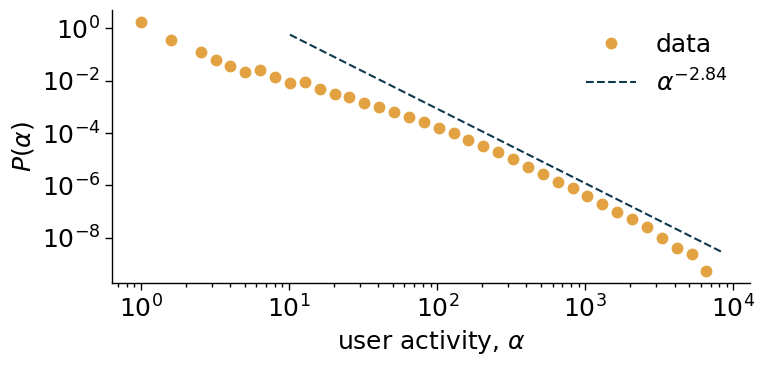

In [8]:
def user_activity_distribution_plot(_fit, _user_activity_distribution):

    powerlaw_exponent = np.round(_fit.alpha,2)

    fig, ax = plt.subplots(1,1, figsize=(8,4))

    bin_edges = np.logspace(np.log10(min(_user_activity_distribution)), np.log10(max(_user_activity_distribution)), num=40)
    density, _ = np.histogram(_user_activity_distribution, bins=bin_edges, density=True)

    plt.loglog(bin_edges[:-1], density, marker='o', linestyle=None, linewidth=0,  color='#E3A242',label='data', markersize=7.5)

    ### trying to guess the exponent just by looking a the log-log plot
    x_new = bin_edges[bin_edges>10]
    plt.loglog(x_new, (4e2)*x_new**(-powerlaw_exponent), linestyle='dashed', color='#0E384D', label=fr'$\alpha^{{-{powerlaw_exponent}}}$')

    ax.set_ylabel(r'$P(\alpha)$', fontsize=text_font)
    ax.set_xlabel(r'user activity, $\alpha$', fontsize=text_font)

    axis_decor(ax, text_font, 5, 3, 1)

    ax.legend(frameon=False, fontsize=text_font)

    plt.tight_layout()
    plt.savefig(figure_directory+'user_activity_distribution.png', dpi=300, bbox_inches='tight', format='png')
    plt.show()

user_activity_distribution_plot(_fit=fit, _user_activity_distribution=_user_activity_distribution)